# CICIoT2023 EDA and Feature Engineering

Explore the dataset, clean the data, do some feature engineering, and prepare the final parquet files for model training. The goal is to deeply check the data distribution, handle imbalances, and build good ratio features before I train the tree-based models.


**Our Sample Data Link:** https://drive.google.com/drive/folders/10UUCoH2rOYkuphwR49xGzVKRnnZszgN8?usp=drive_link

## Step 1: Load Data & First Look

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [5]:
df = pd.read_parquet(r'..\CICIOT2023_sample_7M.parquet')
print(f'Shape: {df.shape}')

Shape: (6999993, 49)


In [6]:
df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label,label_8,label_binary
0,26.916983,324858.1,11.5,82.7,97.329536,97.329536,0.0,0.0,0.0,0.0,...,1.665185e+08,13.5,22.737345,887.291875,637197.788622,1.0,244.60,BenignTraffic,Benign,0
1,226.263575,6053.4,6.4,62.1,0.091045,0.091045,0.0,0.0,0.0,0.0,...,1.668608e+08,13.5,15.363739,142.246215,12111.936873,1.0,244.60,DNS_Spoofing,Spoofing,1
2,69.159983,2000.2,9.3,115.1,3.444647,3.444647,0.0,0.0,0.0,0.0,...,5.106339e-02,5.5,12.583287,45.832472,1743.115492,0.8,38.50,Recon-HostDiscovery,Recon,1
3,0.000000,0.0,1.0,64.0,22.627661,22.627661,0.0,0.0,0.0,0.0,...,8.312409e+07,9.5,9.165151,0.000000,0.000000,0.0,141.55,DDoS-ICMP_Flood,DDoS,1
4,0.000000,54.0,6.0,64.0,2.073164,2.073164,0.0,1.0,0.0,1.0,...,8.334940e+07,9.5,10.392305,0.000000,0.000000,0.0,141.55,DDoS-RSTFINFlood,DDoS,1


In [7]:
df.dtypes

flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          float64
syn_count          float64
fin_count          float64
urg_count          float64
rst_count          float64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IPv                float64
LLC                float64
Tot sum            float64
Min                float64
Max                float64
AVG                float64
S

In [8]:
df.columns.tolist()

['flow_duration',
 'Header_Length',
 'Protocol Type',
 'Duration',
 'Rate',
 'Srate',
 'Drate',
 'fin_flag_number',
 'syn_flag_number',
 'rst_flag_number',
 'psh_flag_number',
 'ack_flag_number',
 'ece_flag_number',
 'cwr_flag_number',
 'ack_count',
 'syn_count',
 'fin_count',
 'urg_count',
 'rst_count',
 'HTTP',
 'HTTPS',
 'DNS',
 'Telnet',
 'SMTP',
 'SSH',
 'IRC',
 'TCP',
 'UDP',
 'DHCP',
 'ARP',
 'ICMP',
 'IPv',
 'LLC',
 'Tot sum',
 'Min',
 'Max',
 'AVG',
 'Std',
 'Tot size',
 'IAT',
 'Number',
 'Magnitue',
 'Radius',
 'Covariance',
 'Variance',
 'Weight',
 'label',
 'label_8',
 'label_binary']

## Step 2: Data Quality Check
Check for missing values, duplicates, and infinite values.

In [9]:
# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values!')

Missing values per column:
No missing values!


In [10]:
# Duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes:}')

Duplicate rows: 6


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
# Infinite values
numeric_cols = df.select_dtypes(include=[np.number]).columns

inf_check = np.isinf(df[numeric_cols]).sum()
print('Infinite values per column:')
print(inf_check[inf_check > 0] if inf_check.sum() > 0 else 'No infinite values!')

Infinite values per column:
No infinite values!


## Step 3: Basic Statistics

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
flow_duration,6999987.0,3.251680e+01,6.831402e+02,0.000000,0.000000e+00,2.664053e-02,3.533473e+00,1.866983e+05
Header_Length,6999987.0,2.189885e+05,7.404545e+05,0.000000,5.400000e+01,1.080000e+02,2.685620e+04,9.890738e+06
Protocol Type,6999987.0,8.647237e+00,7.817090e+00,0.000000,6.000000e+00,6.000000e+00,8.200000e+00,4.700000e+01
Duration,6999987.0,7.525191e+01,3.089602e+01,0.000000,6.400000e+01,6.400000e+01,6.591000e+01,2.550000e+02
Rate,6999987.0,7.640971e+03,8.922950e+04,0.000000,2.905511e+00,2.081618e+01,8.563083e+01,8.388608e+06
Srate,6999987.0,7.640971e+03,8.922950e+04,0.000000,2.905511e+00,2.081618e+01,8.563083e+01,8.388608e+06
Drate,6999987.0,7.804485e-06,1.265219e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,2.971522e+01
fin_flag_number,6999987.0,6.378655e-02,2.443723e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
syn_flag_number,6999987.0,1.618720e-01,3.683334e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
rst_flag_number,6999987.0,7.354999e-02,2.610372e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00


### Quick Data Quality Observations:

- **No Missing Values:** Out of 7M rows, there are no nulls. That's great, no need for imputation.
- **Imbalance:** Huge difference between attack (84.3%) and benign (15.7%). I'll definitely need to use class weights later instead of SMOTE, since SMOTE will kill my RAM on 7M rows.
- **Useless columns:** `IPv` and `LLC` are basically 1 everywhere. I should just drop them.
- **Skewness:** A lot of network features like `Rate` have massive outliers compared to their median. I will need log transforms and RobustScaler down the line.
- **Sparsity:** Many columns have mostly zeros. Tree models like XGBoost handle this fine.

In [14]:
# skewness  anything > 10 needs log transform
skew = df[numeric_cols].skew().sort_values(ascending=False)
print('Skewness (top 15):')
print(skew.head(15))
print('\nHighly skewed features (>10):', skew[skew.abs() > 10].index.tolist())

Skewness (top 15):
Telnet             2645.748854
Drate              2102.760382
SMTP               1527.523159
IRC                 999.997786
cwr_flag_number     836.657636
DHCP                763.760106
ece_flag_number     683.127367
fin_count            72.348106
flow_duration        63.447699
SSH                  60.497923
ARP                  57.113230
DNS                  42.265400
Rate                 25.050093
Srate                25.050093
Covariance           24.441161
dtype: float64

Highly skewed features (>10): ['Telnet', 'Drate', 'SMTP', 'IRC', 'cwr_flag_number', 'DHCP', 'ece_flag_number', 'fin_count', 'flow_duration', 'SSH', 'ARP', 'DNS', 'Rate', 'Srate', 'Covariance', 'urg_count', 'LLC', 'IPv']


### Why check for Skewness > 10?

Usually, >1 means highly skewed. But this is network traffic massive spikes are normal during an attack (like DDoS flooding millions of bytes). If I filter by >1, almost everything gets flagged. By using >10, I can focus on the truly extreme columns that desperately need a log transform so they don't break the models later.

In [15]:
# Check for negative values
print('Features with negative values:\n')

numeric_cols = df.select_dtypes(include=['number']).columns

neg_counts = df[numeric_cols].lt(0).sum() # lt is less than 
neg_cols = neg_counts[neg_counts > 0]

if not neg_cols.empty:
    for col, count in neg_cols.items():
        print(f'  {col}: {count:,} ({count / len(df) * 100:.4f}%)')
else:
    print('  None found')


Features with negative values:

  None found


I also wrote a quick check to see if there are any negative values in the numeric columns. Why? Because things like `flow_duration` or `Header_Length` can't mathematically be negative. If there were negative numbers, it would mean a bug in the logging system, and I'd have to drop or fix those rows. Luckily, the output is empty, so the dataset is safe from negative artifacts.

## Step 4: Target Variable (Label Distribution)
To understanding the attack types.

### 4a. Binary: Benign vs Attack

In [16]:
print('Binary Distribution:')
print(df['label_binary'].value_counts())


Binary Distribution:
label_binary
1    5901792
0    1098195
Name: count, dtype: int64


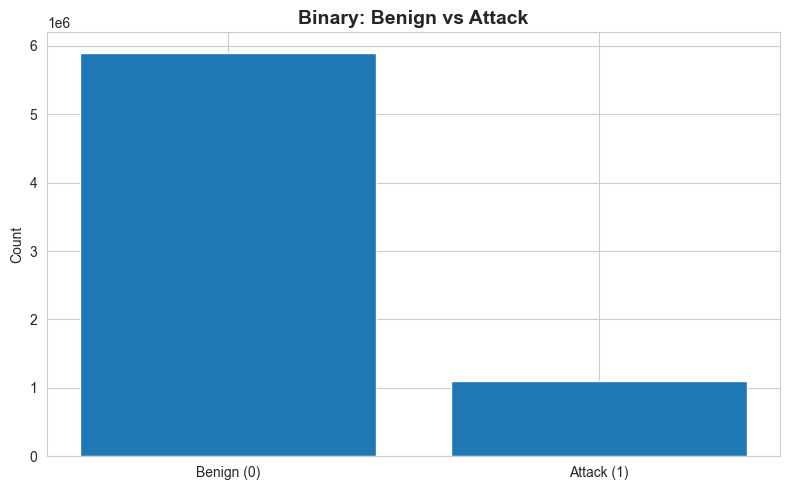

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['label_binary'].value_counts()

bars = ax.bar(['Benign (0)', 'Attack (1)'], counts.values)
ax.set_title('Binary: Benign vs Attack', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 4b. 8-Class Distribution

In [18]:
print('8-Class Distribution:')
print(df['label_8'].value_counts())

8-Class Distribution:
label_8
DDoS          4049367
Benign        1098195
DoS            956526
Recon          354560
Mirai          290602
Spoofing       212844
Web             24829
BruteForce      13064
Name: count, dtype: int64


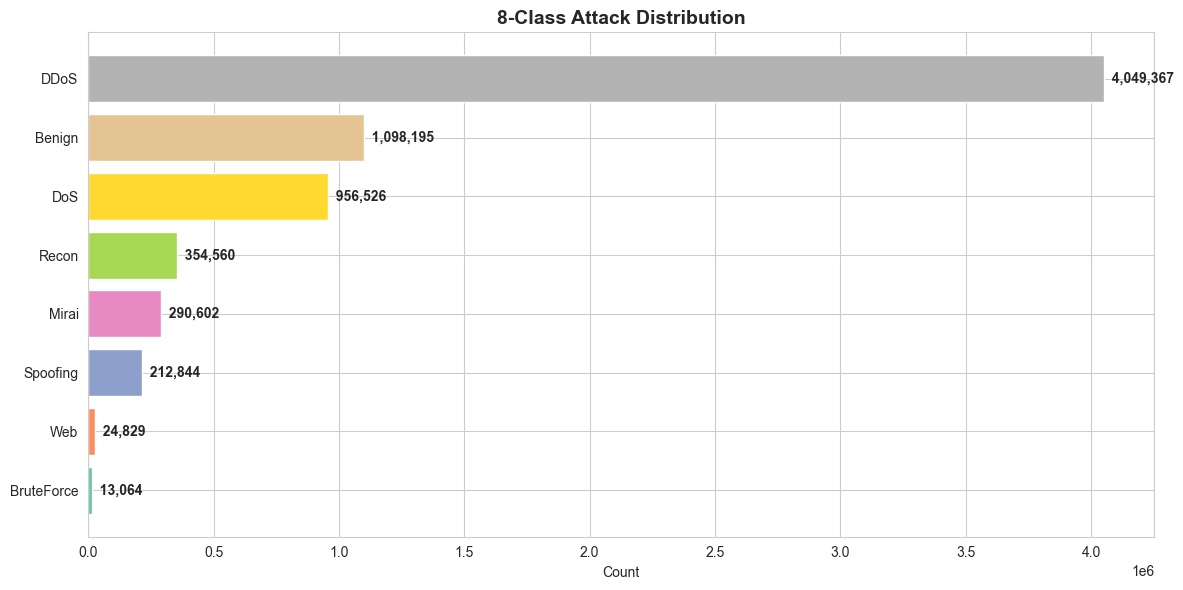

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

counts_8 = df['label_8'].value_counts().sort_values()
bars = ax.barh(counts_8.index, counts_8.values, color=sns.color_palette('Set2', len(counts_8)))

for i, val in enumerate(counts_8.values):
    ax.text(val, i, f'  {val:,}', va='center', fontweight='bold')

ax.set_title('8-Class Attack Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

### 4c. Full 34-Class Distribution

In [20]:
print('34-Class Distribution:')
print(df['label'].value_counts().to_string())

34-Class Distribution:
label
BenignTraffic              1098195
DDoS-ICMP_Flood             794378
DDoS-UDP_Flood              597097
DDoS-TCP_Flood              496194
DDoS-PSHACK_Flood           451744
DDoS-SYN_Flood              447820
DDoS-RSTFINFlood            446286
DDoS-SynonymousIP_Flood     396955
DoS-UDP_Flood               366116
DoS-TCP_Flood               294720
DDoS-ACK_Fragmentation      285104
DoS-SYN_Flood               223826
DNS_Spoofing                178910
Recon-HostDiscovery         134377
Mirai-greeth_flood          109425
Recon-OSScan                 98259
Mirai-udpplain               98250
Mirai-greip_flood            82927
Recon-PortScan               82280
DoS-HTTP_Flood               71864
DDoS-ICMP_Fragmentation      49919
VulnerabilityScan            37382
MITM-ArpSpoofing             33934
DDoS-UDP_Fragmentation       31654
DDoS-HTTP_Flood              28790
DDoS-SlowLoris               23426
DictionaryBruteForce         13064
BrowserHijacking          

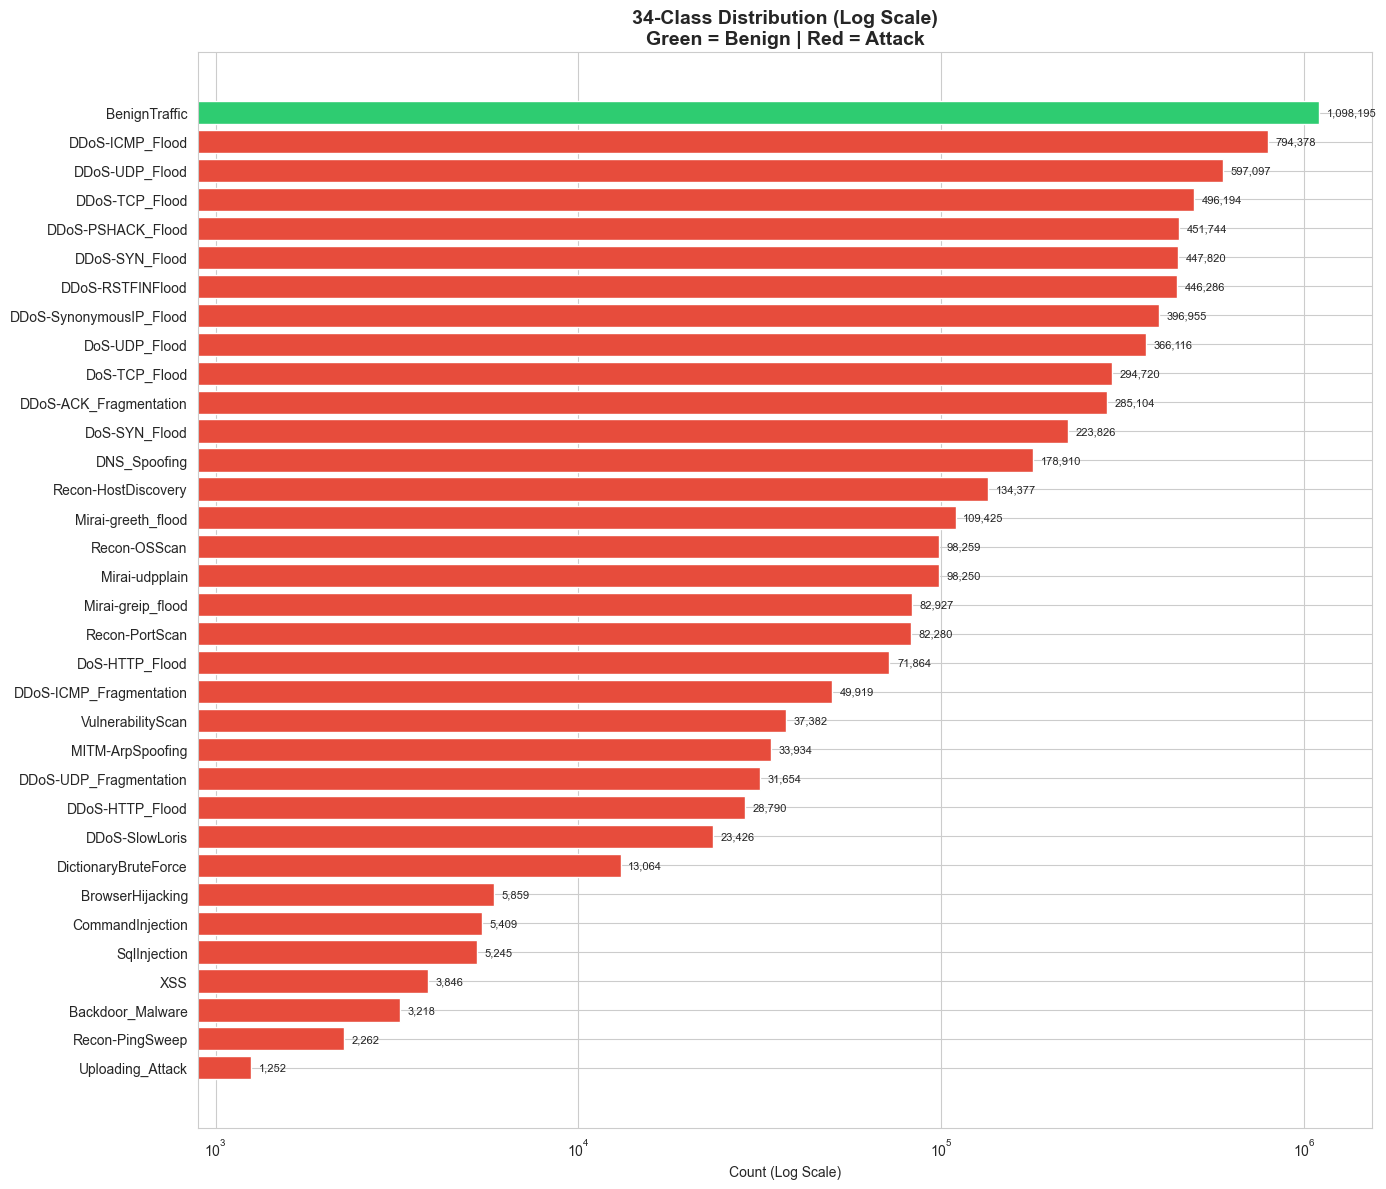

In [21]:
fig, ax = plt.subplots(figsize=(14, 12))

counts_34 = df['label'].value_counts().sort_values()
colors = ['#2ecc71' if l == 'BenignTraffic' else '#e74c3c' for l in counts_34.index]

ax.barh(counts_34.index, counts_34.values, color=colors)

for i, val in enumerate(counts_34.values):
    ax.text(val * 1.05, i, f'{val:,}', va='center', fontsize=8)

ax.set_xscale('log')
ax.set_title('34-Class Distribution (Log Scale)\nGreen = Benign | Red = Attack',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Count (Log Scale)')
plt.tight_layout()
plt.show()

### Dealing with this massive class imbalance

Looking at the 34-class distribution, some attacks have millions of rows while others only have around 1,000. 

My strategy to handle this is:
1. **Hierarchical Classification:** Instead of training one mega-model to predict 34 classes, I should train a Binary model first (Attack vs Benign), then an 8-Class model, etc. It separates the problem and helps the model focus.
2. **Class Weights:** I'll pass `class_weight='balanced'` to sklearn or `sample_weight` to XGBoost. This forces the model to actually care about the minority classes instead of just predicting DDoS for everything to get high accuracy.
3. **Combine rare classes:** For some very rare web attacks, I might just merge them together to give the model a better chance.

In [22]:
# Rare classes (< 10,000 samples)
rare = counts_34[counts_34 < 10_000]
print(f'Rare classes (< 10,000 samples): {len(rare)}')
print(rare)

Rare classes (< 10,000 samples): 7
label
Uploading_Attack    1252
Recon-PingSweep     2262
Backdoor_Malware    3218
XSS                 3846
SqlInjection        5245
CommandInjection    5409
BrowserHijacking    5859
Name: count, dtype: int64


## Step 5: Feature Distributions
Understanding what each feature looks like — histograms and box plots.

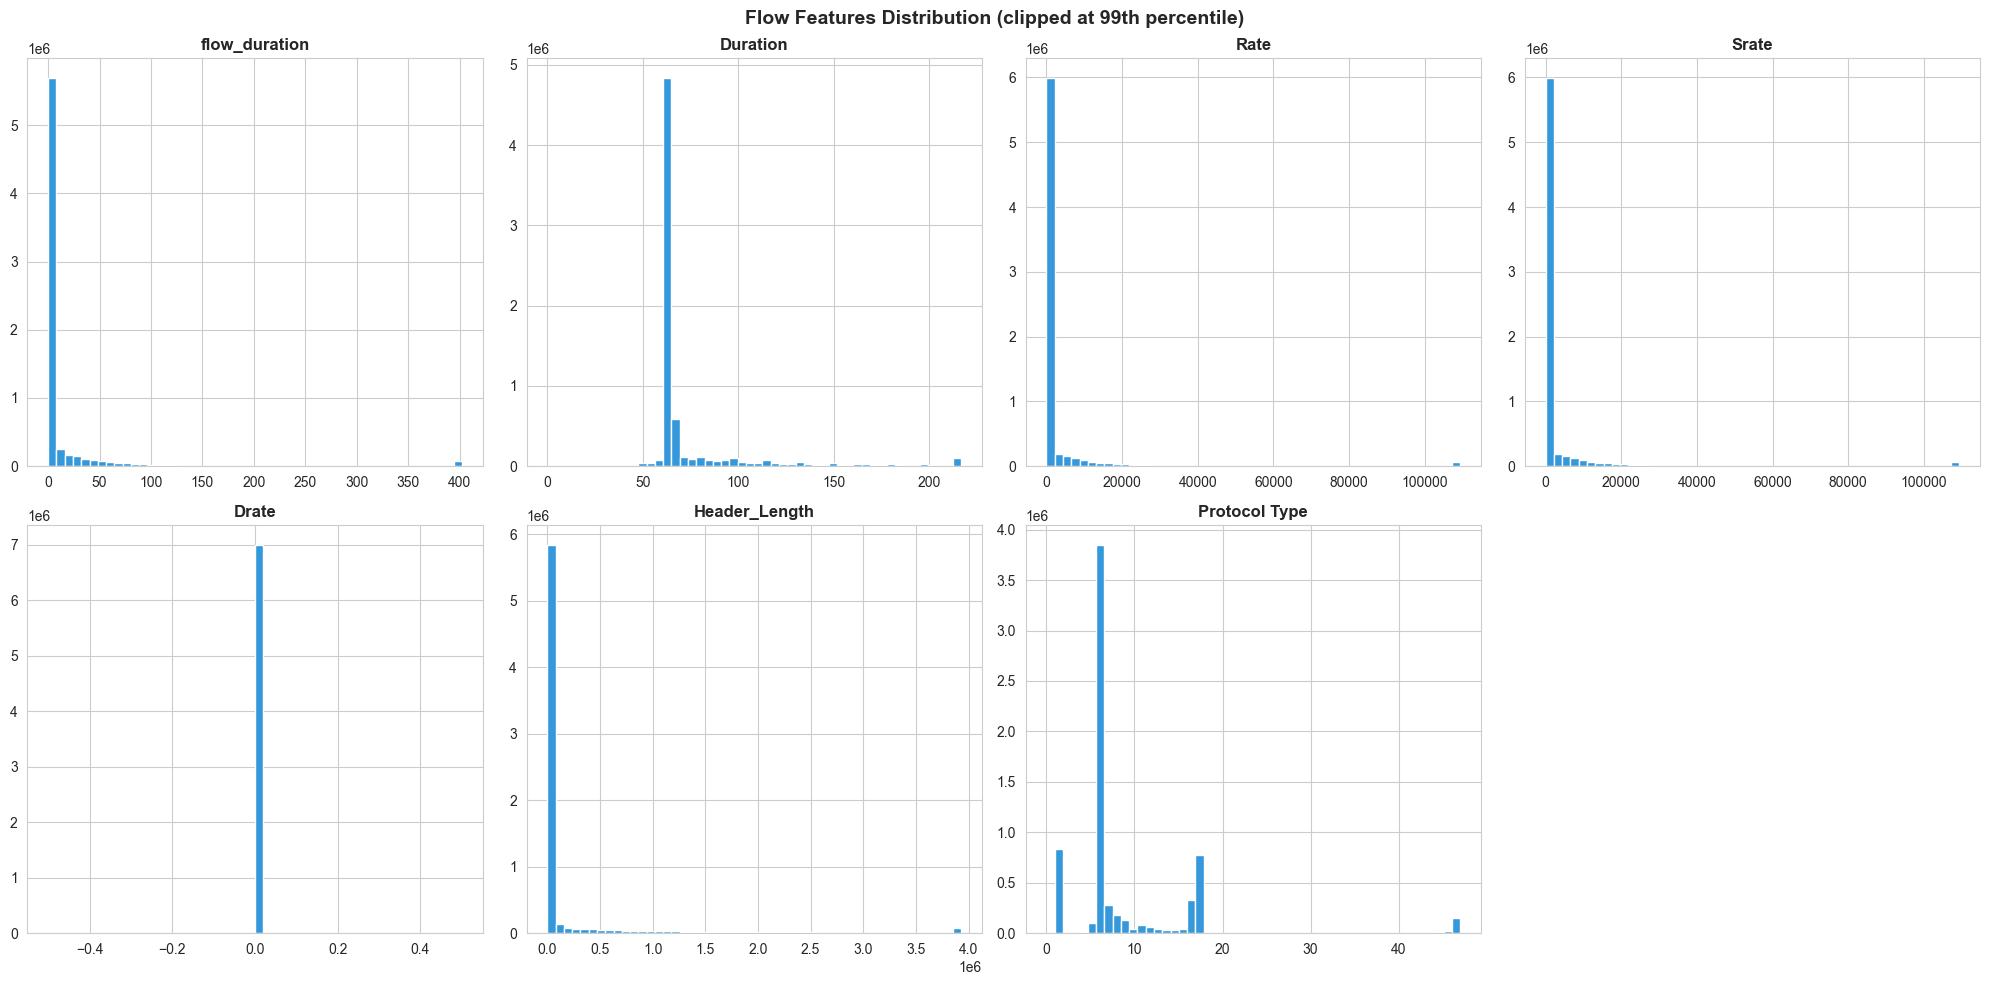

In [23]:
# Flow features
flow_cols = ['flow_duration', 'Duration', 'Rate', 'Srate', 'Drate', 'Header_Length', 'Protocol Type']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(flow_cols):
    data = df[col].clip(upper=df[col].quantile(0.99))  # clip outliers for better view
    axes[i].hist(data, bins=50, color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')

axes[-1].set_visible(False)  # hide extra subplot
plt.suptitle('Flow Features Distribution (clipped at 99th percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Flow Features Distribution

All 7 flow features are **heavily right-skewed**, with most values concentrated near zero and a long tail stretching to the right. This pattern is expected in network security data.

- **`flow_duration`**: Most connections are very short (close to zero seconds), suggesting automated attack traffic like port scans or flood attacks that happen in quick bursts.
- **`Duration`**: Most sessions cluster around 64 seconds, which likely reflects the fixed tithe window used during data collection.
- **`Rate` & `Srate`**: Nearly identical distributions, both extremely compressed near zero. This means most traffic is **one-directional** with no response from the destination — a classic signature of DDoS/DoS flood attacks.
- **`Drate`**: Almost entirely zero, confirming that the destination rarely sends anything back.
- **`Header_Length`**: Massive spike near zero but a very long tail reaching into the millions. Sothe packets have abnormally large headers, which could indicate **header manipulation** by attackers.
- **`Protocol Type`**: A few discrete spikes rather than a smooth distribution. The dominant values around 6 and 17 correspond to **TCP** and **UDP** protocols.


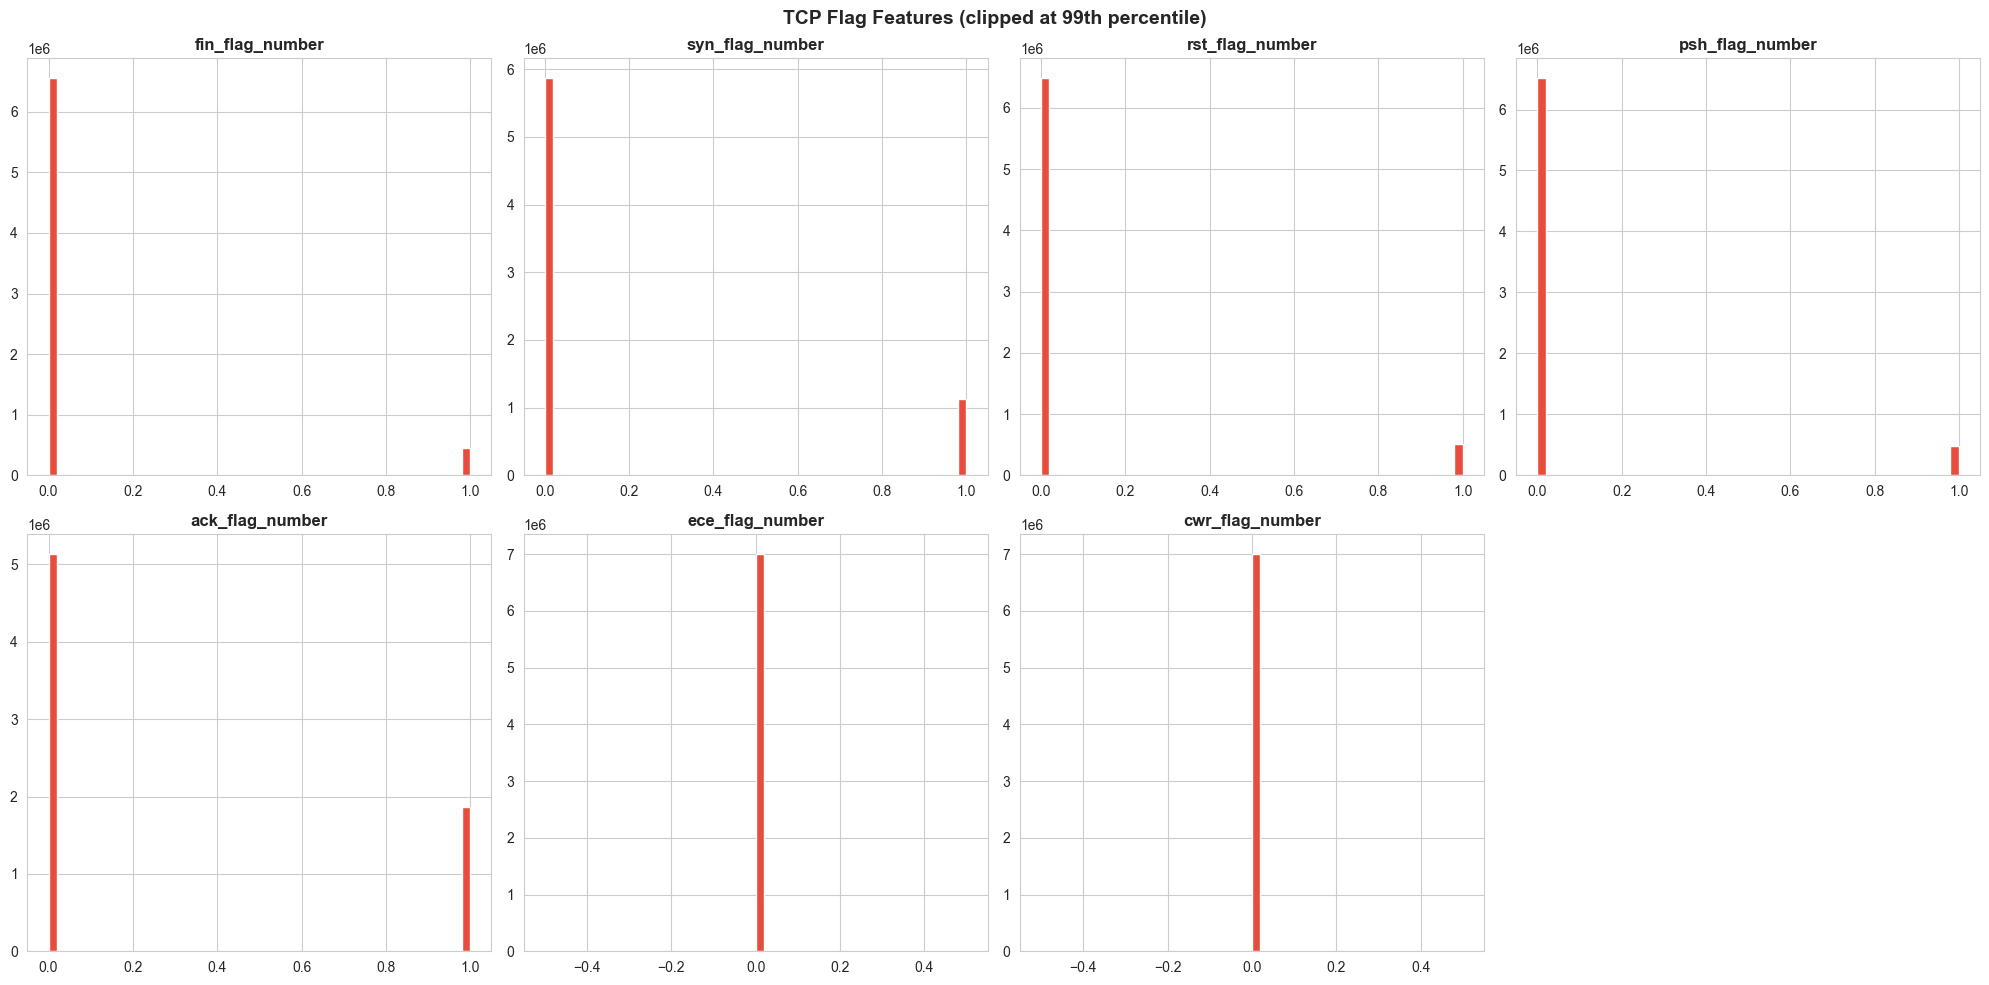

In [24]:
# TCP Flag features
flag_cols = ['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number',
             'ack_flag_number', 'ece_flag_number', 'cwr_flag_number']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(flag_cols):
    data = df[col].clip(upper=df[col].quantile(0.99))
    axes[i].hist(data, bins=50, color='#e74c3c', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')

axes[-1].set_visible(False)
plt.suptitle('TCP Flag Features (clipped at 99th percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

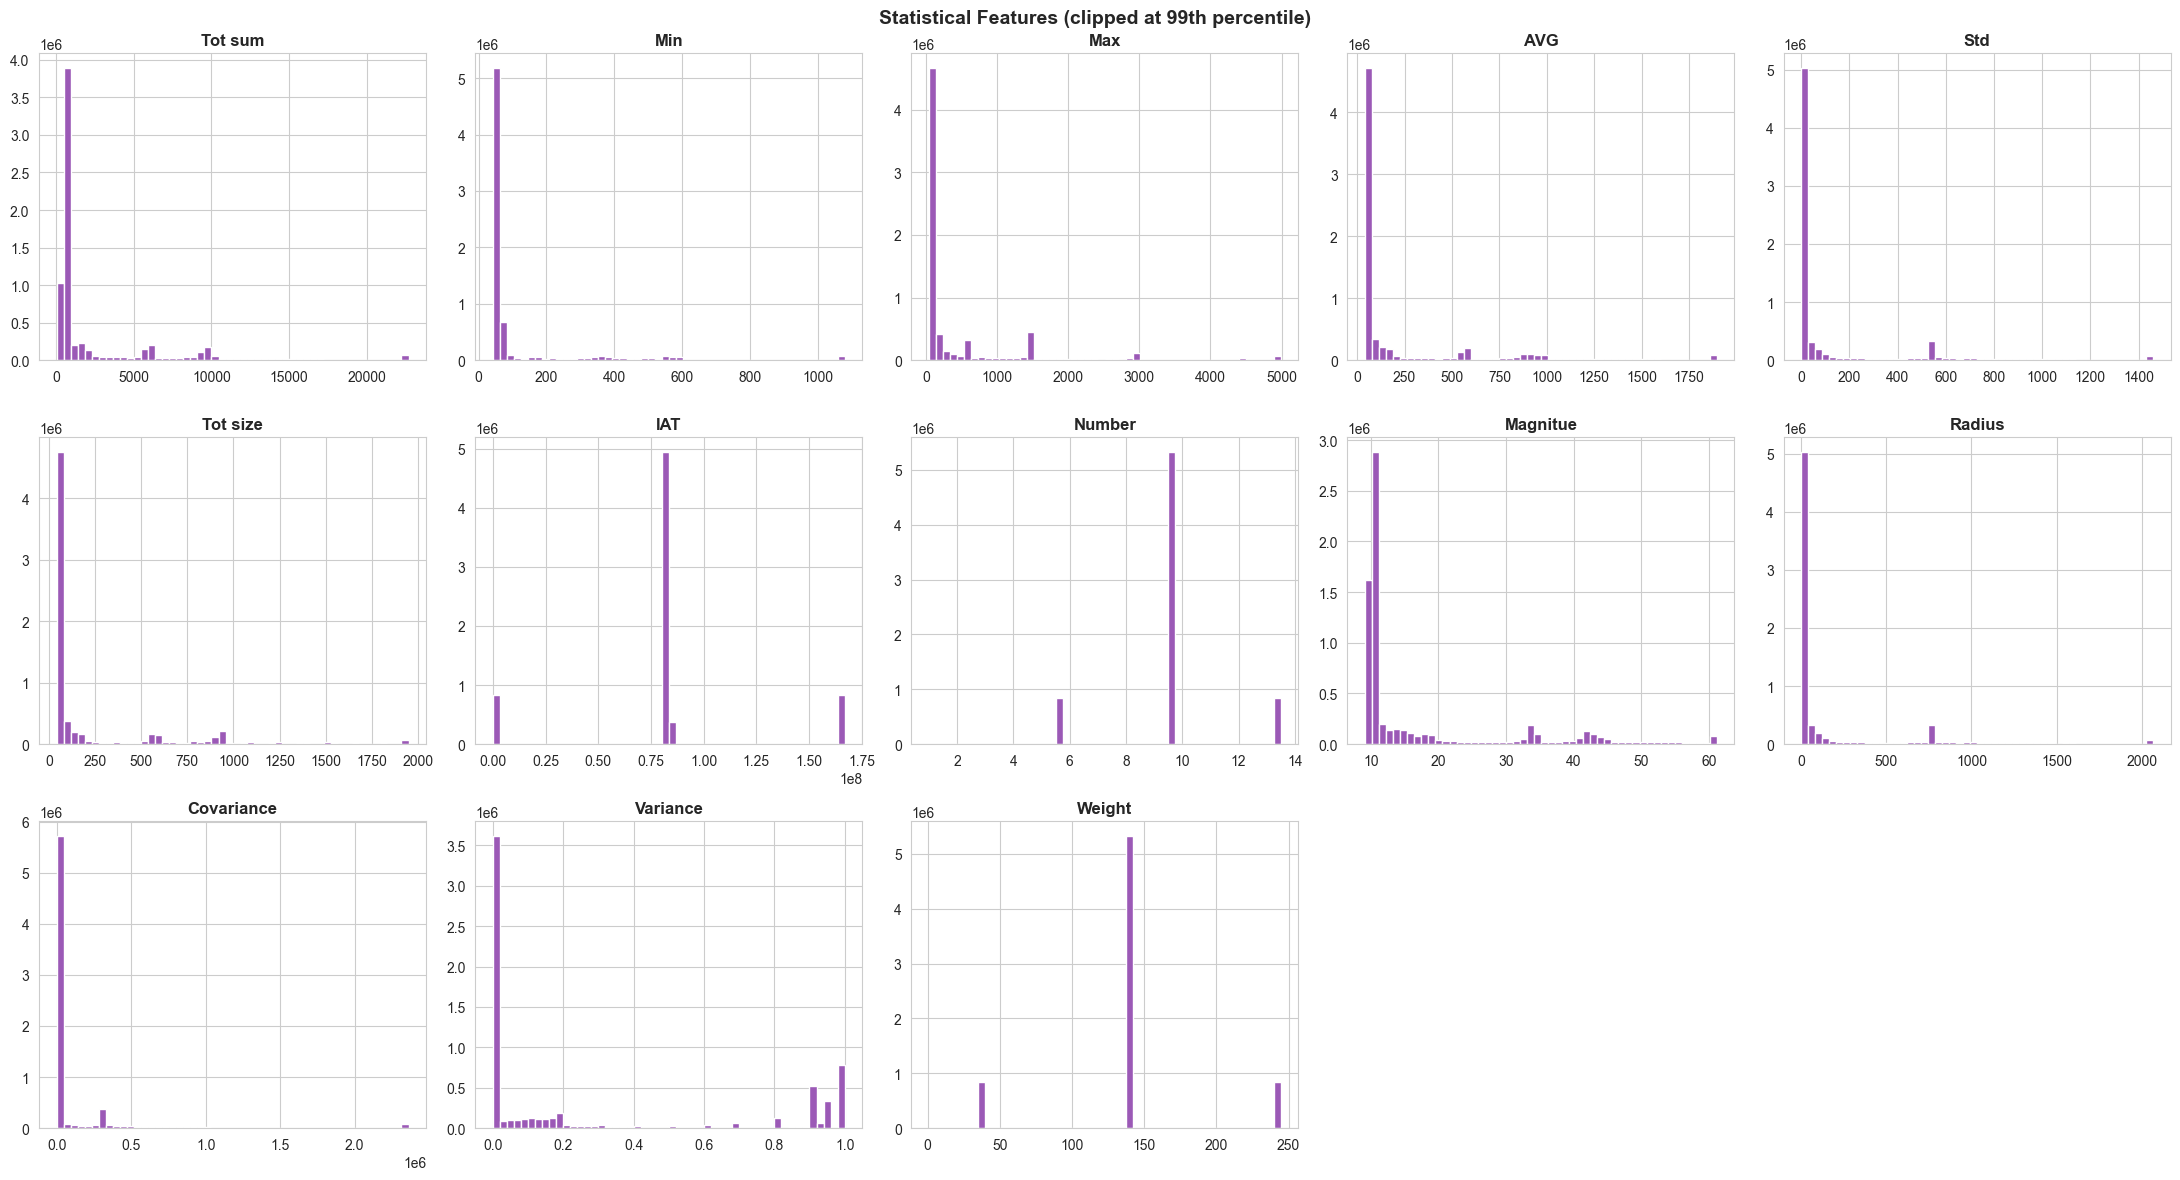

In [25]:
# Statistical aggregate features
stat_cols = ['Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT',
             'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight']

fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()

for i, col in enumerate(stat_cols):
    data = df[col].clip(upper=df[col].quantile(0.99))
    axes[i].hist(data, bins=50, color='#9b59b6', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')

for j in range(len(stat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Statistical Features (clipped at 99th percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Statistical Features Review

- `Tot sum`, `Min`, `Max`, `AVG`, etc. are all heavily skewed. I will log transform them.
- `IAT` (Inter-Arrival Time) is weirdly clustered around 83 million. The delay between packets is almost exactly the same across the board, which screams 'automated bot traffic'.
- `Number` is basically fixed at 9.5 packets. This is probably just because of how the dataset was recorded in windows. I might drop it later if the feature importance is 0.
- `Variance` has a spike at 0 (all packets same size = flood) and another near 1 (varying sizes = normal).

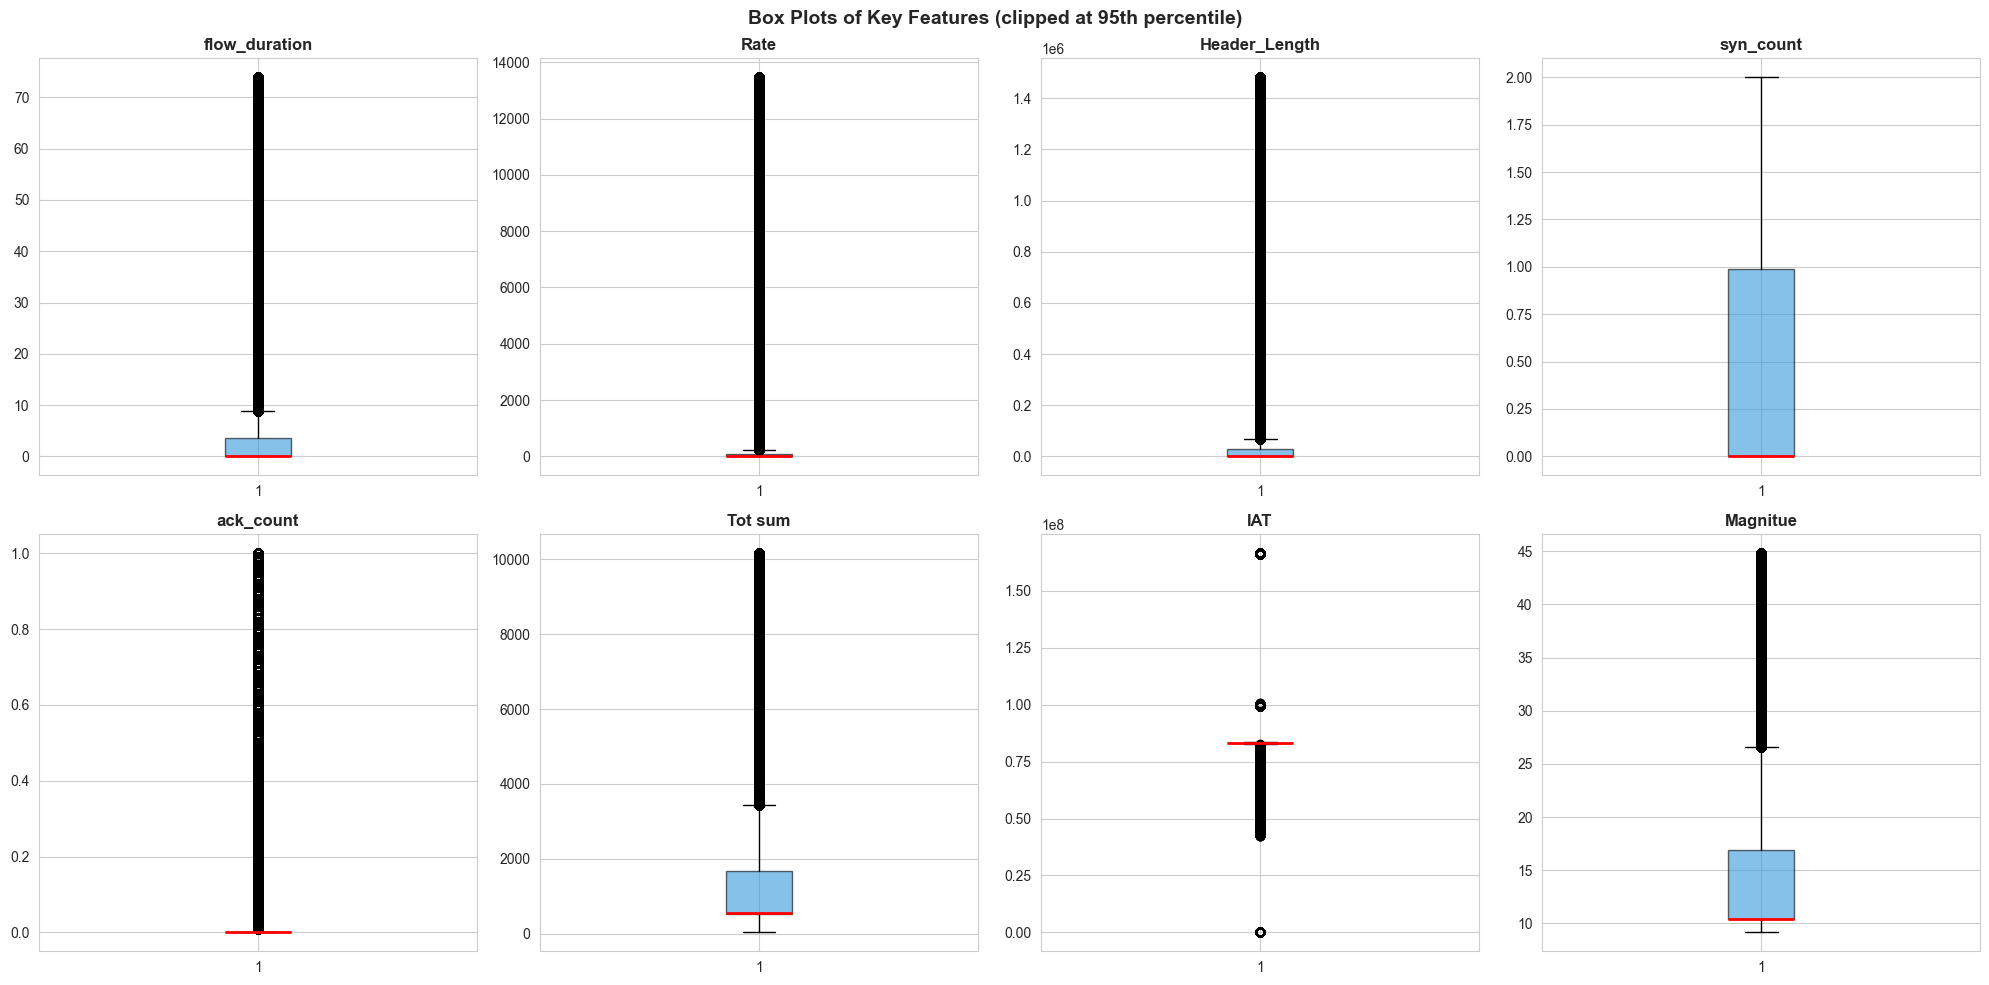

In [26]:
# Box plots for key features
key_features = ['flow_duration', 'Rate', 'Header_Length', 'syn_count',
                'ack_count', 'Tot sum', 'IAT', 'Magnitue']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    data = df[col].clip(upper=df[col].quantile(0.95))  # clip to see the box
    axes[i].boxplot(data.dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Box Plots of Key Features (clipped at 95th percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Box Plots of Key Features

These box plots reveal the spread and outlier behavior of the most important features (clipped at the 95th percentile for visibility).

- `flow_duration`, `Rate`, `Header_Length`, and `ack_count` have crazy outliers stretching way up. This perfectly confirms the skewness.
- `syn_count` and `Magnitue` actually have a decent spread (wider boxes). This means they vary a lot between different flows, making them super useful for the models to learn from.
- `IAT` is just a high flat line, basically a constant.

Because of the extreme outliers in almost all the important features, I will use `RobustScaler` instead of a standard scaler.

## Step 6: Features by Attack Type
How do features behave differently for each attack category?

In [27]:
# Use a smaller sample for violin plots (faster)
df_small = df.sample(n=200_000, random_state=42)

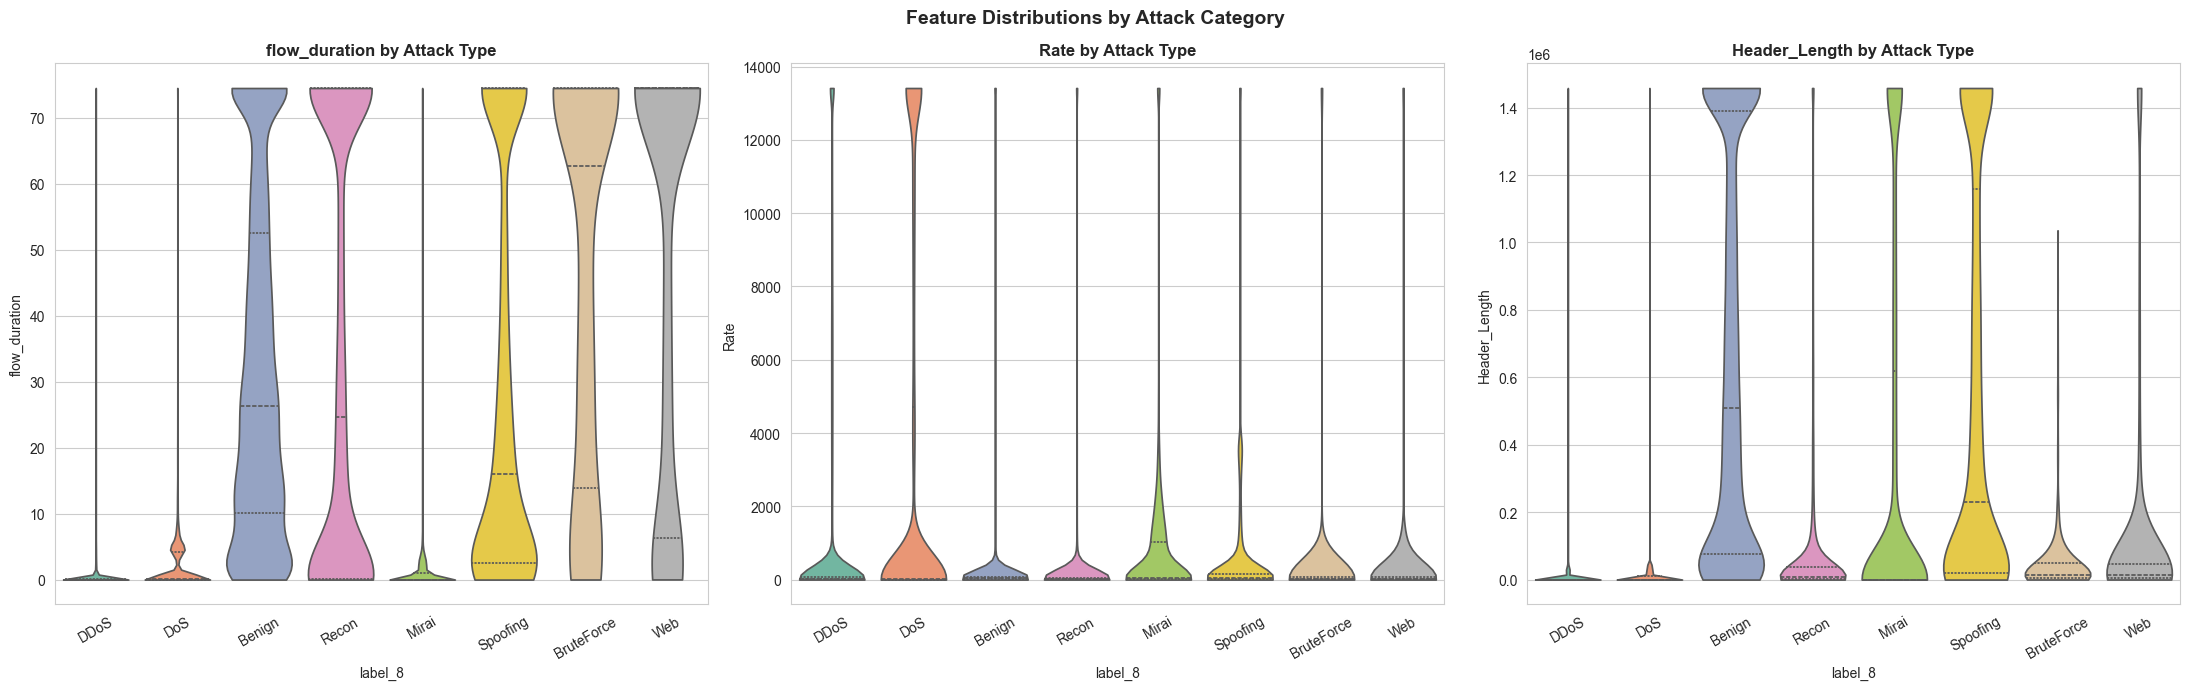

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, col in enumerate(['flow_duration', 'Rate', 'Header_Length']):
    data = df_small.copy()
    data[col] = data[col].clip(upper=data[col].quantile(0.95))
    sns.violinplot(data=data, x='label_8', y=col, ax=axes[i],
                   palette='Set2', inner='quartile', cut=0)
    axes[i].set_title(f'{col} by Attack Type', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Feature Distributions by Attack Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Differences Across Attack Types

**This is Checking which features actually help the model**. A feature is useful only if its distribution changes noticeably between classes. If it looks the same everywhere, the model cannot learn anything from it.

Each violin shape represents how the data is distributed for a specific attack category. A **wide violin** means many data points at that value. A **thin violin** means very few.

---
- **`flow_duration`:** DDoS and DoS are compressed at 0 (fast floods). Benign and Recon are spread out (slower connections). This is a really strong feature.
- **`Rate`:** Almost all classes look identical here. It's not a great feature on its own, but might work well in interactions.
- **`Header_Length`:** Benign traffic uses big headers. DDoS uses tiny headers. Tree models will love this feature.

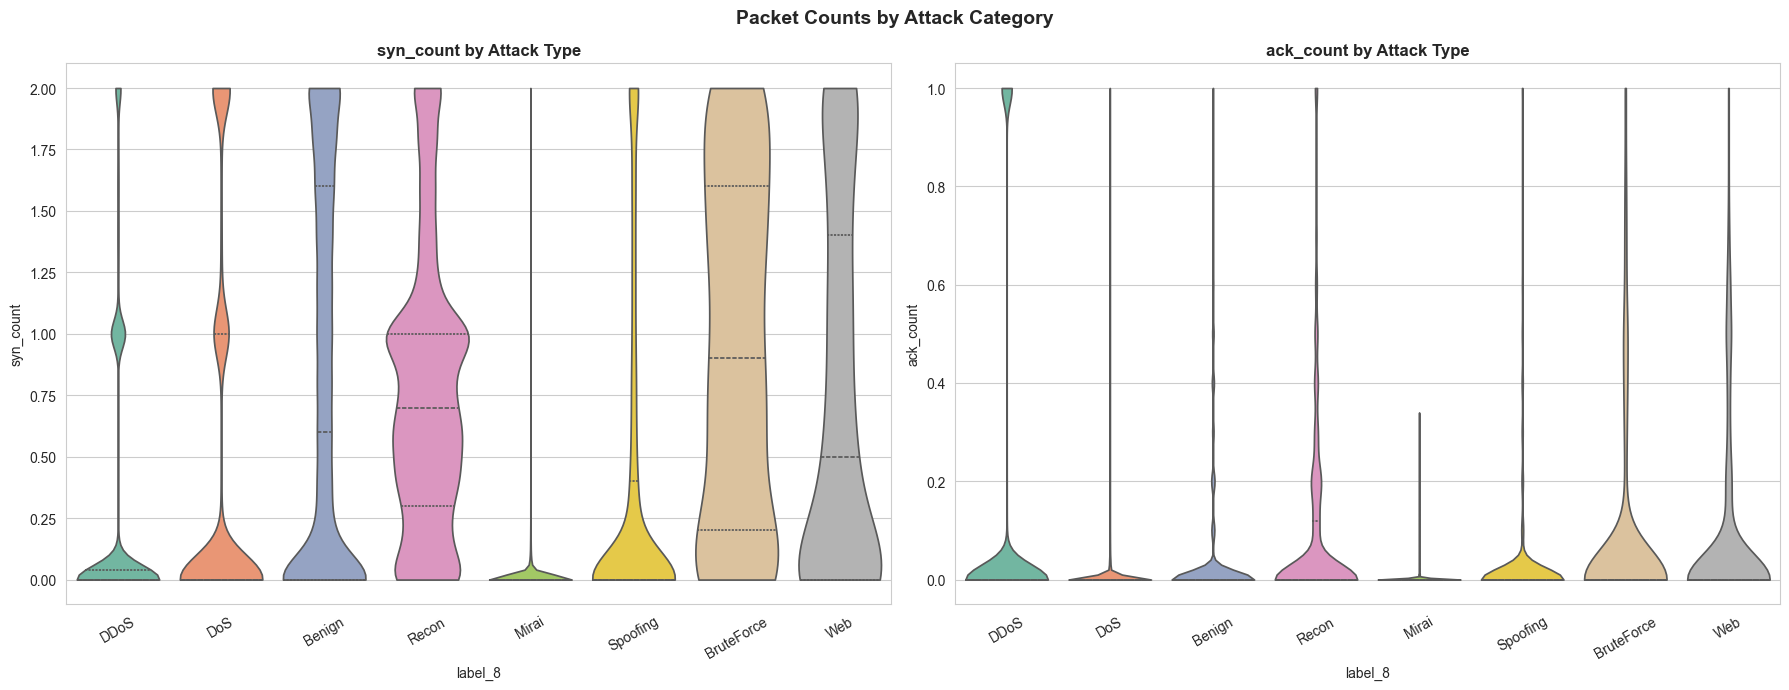

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, col in enumerate(['syn_count', 'ack_count']):
    data = df_small.copy()
    data[col] = data[col].clip(upper=data[col].quantile(0.95))
    sns.violinplot(data=data, x='label_8', y=col, ax=axes[i],
                   palette='Set2', inner='quartile', cut=0)
    axes[i].set_title(f'{col} by Attack Type', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Packet Counts by Attack Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Packet Count Patterns

- **`syn_count`:** BruteForce has a huge spread because every password guess is a new SYN connection. Mirai uses UDP, so its SYN is practically 0. Great feature.
- **`ack_count`:** Almost everything is 0. Most attacks here are one-way (no ACK replies). BruteForce has a slight tail. Not very discriminative overall.

In [30]:
# Mean of key features per attack type
mean_by_attack = df.groupby('label_8')[key_features].mean()
mean_by_attack

,flow_duration,Rate,Header_Length,syn_count,ack_count,Tot sum,IAT,Magnitue
label_8,,,,,,,,
Benign,39.406807,1950.768858,1.009552e+06,0.799766,0.043196,6496.255350,8.329213e+07,29.936528
BruteForce,688.027789,1356.969689,4.876024e+04,0.981611,0.090286,2935.385049,8.332526e+07,20.294026
DDoS,0.812243,9265.254876,7.855930e+03,0.315261,0.114019,1358.465261,8.319528e+07,13.078482
DoS,2.640935,10920.068370,9.523625e+03,0.495314,0.008656,1017.552419,8.296977e+07,12.206579
Mirai,1.397254,8096.836324,5.254825e+05,0.014589,0.001320,5945.999029,8.362162e+07,33.596313
Recon,256.708332,1642.729686,1.006558e+05,0.769315,0.104039,2349.677745,8.330566e+07,17.621422
Spoofing,334.923643,1814.792444,8.833473e+05,0.378211,0.032970,6058.212231,8.339159e+07,28.786176
Web,274.928106,1660.432195,2.522758e+05,0.733142,0.085902,3997.874639,8.364016e+07,23.310354


### Checking the Means

Just validating my visual findings with raw numbers:
- `flow_duration`: DDoS is ~0.8s, BruteForce is ~688s (password guessing takes time).
- `Header_Length`: Benign is ~1M, DDoS is ~7.8K.
- `syn_count`: BruteForce is nearly 1 per packet, Mirai is 0.01.
- `IAT`: ~83M for everything. Totally useless.

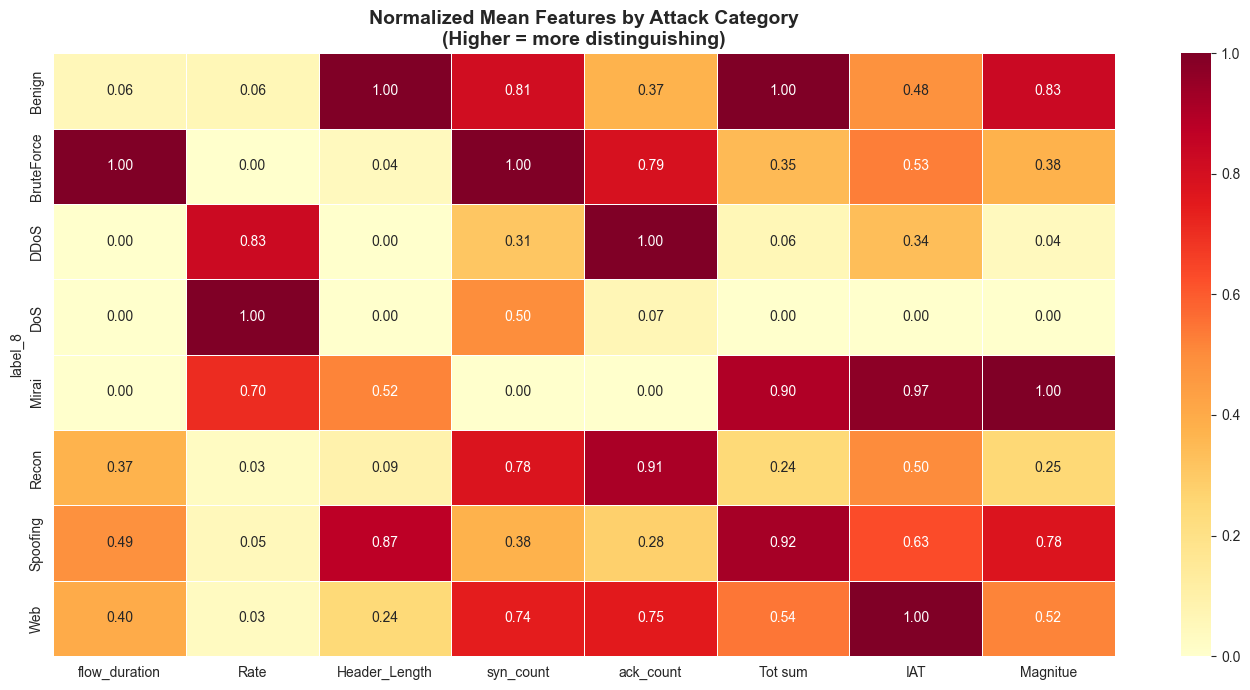

In [31]:
# Heatmap: normalized mean features per attack type
fig, ax = plt.subplots(figsize=(14, 7))

# Normalize each column 0-1 for fair comparison
norm = (mean_by_attack - mean_by_attack.min()) / (mean_by_attack.max() - mean_by_attack.min() + 1e-10)

sns.heatmap(norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Normalized Mean Features by Attack Category\n(Higher = more distinguishing)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Normalized Heatmap

This scaled heatmap just gives a final overview of what attacks trigger which features the hardest.
- BruteForce = high duration & SYN.
- DoS = high rate.
- Benign = high header length.

Features with lots of color variation across the rows (`Header_Length`, `flow_duration`) are what my trees will split on the most.

## Step 7: Correlation Analysis
Find which features are related to each other.

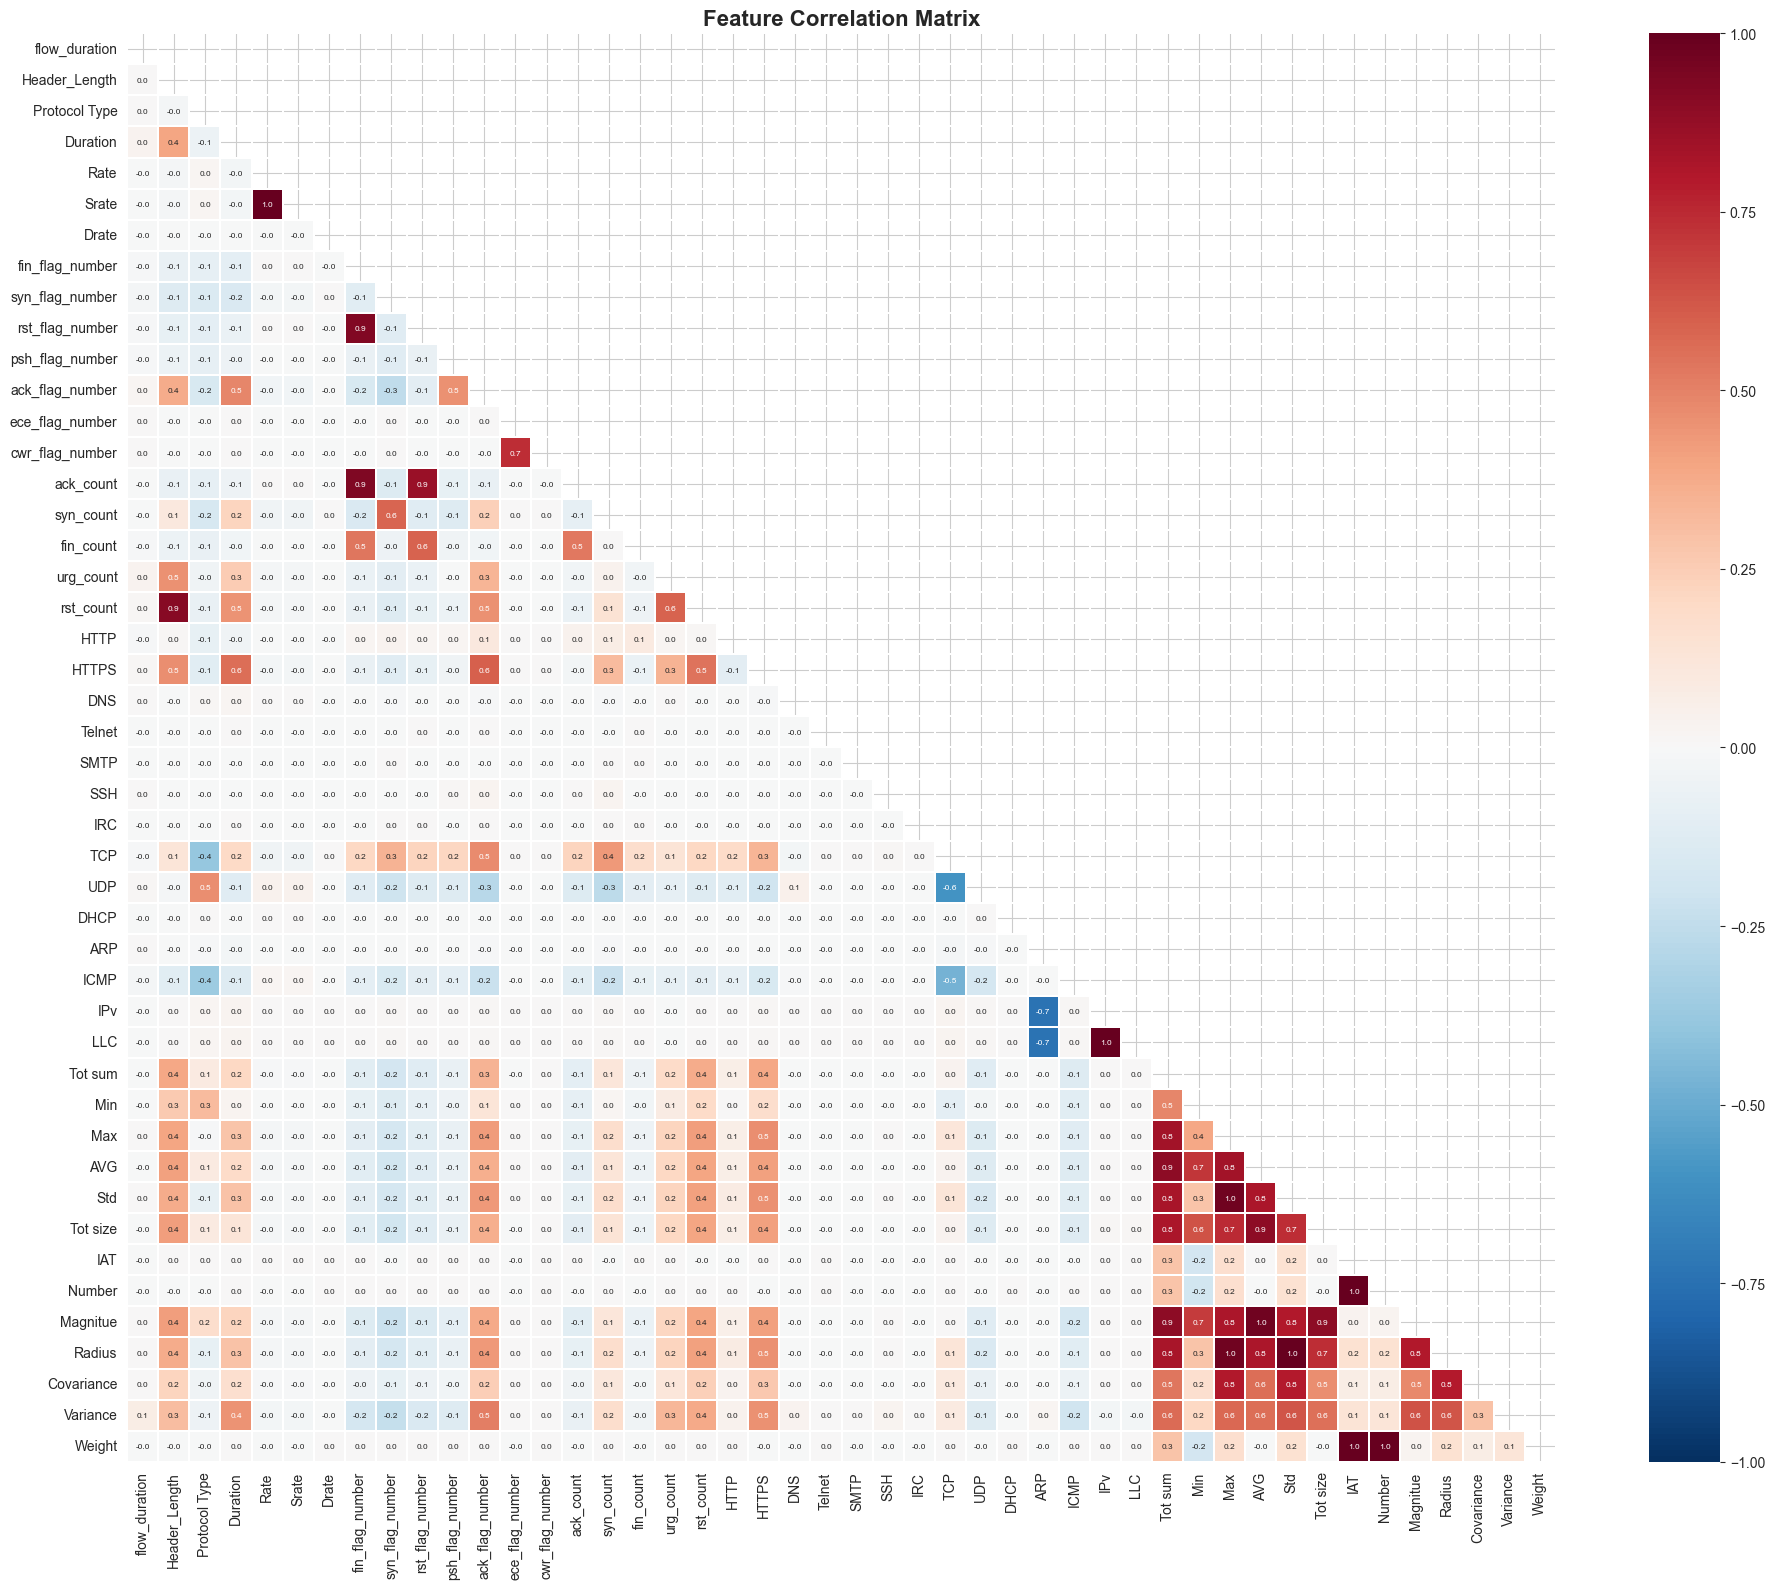

In [32]:
# Full correlation matrix
feature_cols = [c for c in numeric_cols if c != 'label_binary']
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, ax=ax ,annot=True, fmt='.1f',annot_kws={'size': 6})

ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Matrix - Dropping Duplicates

I need to drop highly correlated columns to speed up training and prevent memory crashes.
- `Rate` and `Srate` are a 1.0 perfect match. I'll drop `Srate`.
- `IPv` and `LLC` are basically 0.999. I'll drop `LLC`.
- The bottom right block (`Tot sum`, `Min`, `Max`, `AVG`, `Std`) are all heavily correlated since they describe the same thing (packet size math). I should drop most of them and just keep 2 or 3 representations.

In [33]:
# Find highly correlated pairs (|r| > 0.9)
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 4)))

print(f'Highly correlated pairs (|r| > 0.9): {len(high_corr)}')
for c1, c2, r in high_corr:
    print(f'  {c1:<25} <-> {c2:<25}: r = {r}')

Highly correlated pairs (|r| > 0.9): 12
  Header_Length             <-> rst_count                : r = 0.9095
  Rate                      <-> Srate                    : r = 1.0
  fin_flag_number           <-> rst_flag_number          : r = 0.9248
  fin_flag_number           <-> ack_count                : r = 0.9316
  IPv                       <-> LLC                      : r = 1.0
  Max                       <-> Std                      : r = 0.9711
  Max                       <-> Radius                   : r = 0.9711
  AVG                       <-> Magnitue                 : r = 0.9694
  Std                       <-> Radius                   : r = 1.0
  IAT                       <-> Number                   : r = 0.998
  IAT                       <-> Weight                   : r = 0.9984
  Number                    <-> Weight                   : r = 0.9999


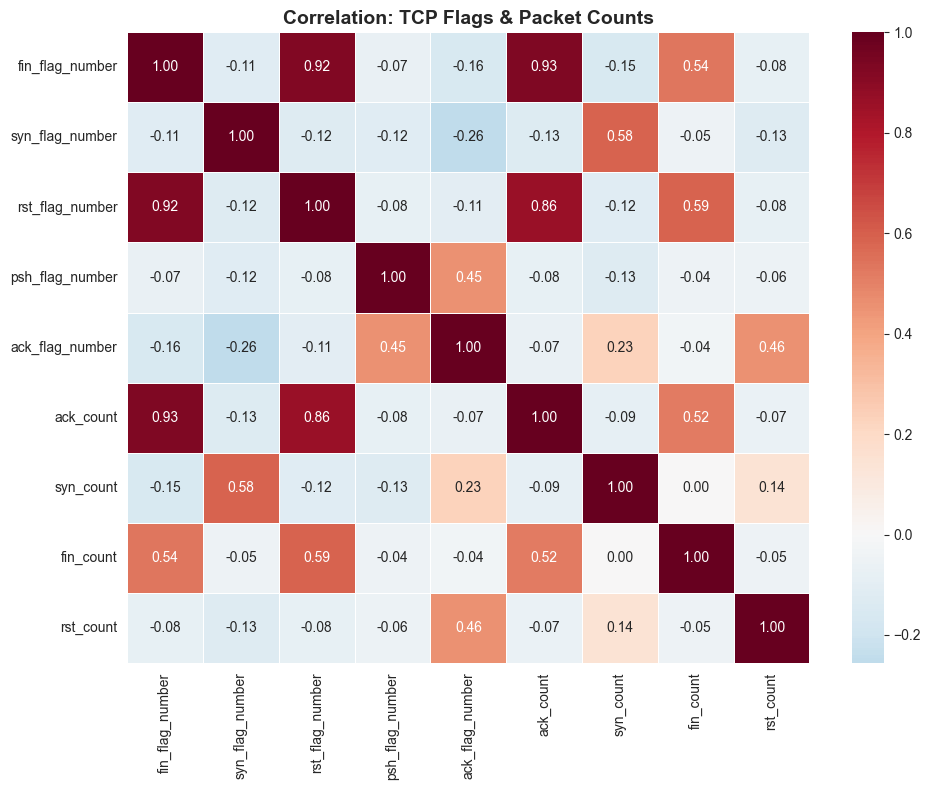

In [34]:
# Focused correlation: TCP flags and packet counts
flag_packet_cols = ['fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number',
                    'ack_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[flag_packet_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation: TCP Flags & Packet Counts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### TCP Flags vs Packet Counts

- `fin_flag_number`, `rst_flag_number`, and `ack_count` are highly correlated > 0.9. They all happen together when a connection forces a close. I'll just keep `ack_count`.
- `syn_flag_number` and `syn_count` are only 0.58. One means 'did it happen', the other means 'how many times'. Both are useful, I'll keep both.

## Step 9: Outlier Detection
In security data, outliers might be actual attacks — don't remove them blindly!

In [ ]:
# IQR-based outlier detection for key features
print('Outlier percentages for key features:')
print(f'{"Feature":<25} {"Outlier %":<12} {"Count":<15}')
print('-' * 55)

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    print(f'{col:<25} {pct:<12.2f} {n_out:<15,}')

In [ ]:
# Compare outlier rates: Benign vs Attack
numeric_cols = df.select_dtypes(include='number').columns

print('Outlier percentages for ALL numeric features:')
print(f'{"Feature":<25} {"Outlier %":<12} {"Count":<15}')
print('-' * 55)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:  # skip near-constant features
        continue
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    print(f'{col:<25} {pct:<12.2f} {n_out:<15,}')


print('\nNote: In security data, outliers in benign traffic could be undetected attacks.')
print('Do NOT blindly remove outliers!')

Outlier percentages for ALL numeric features:
Feature                   Outlier %    Count          
-------------------------------------------------------
flow_duration             18.23        1,275,753      
Header_Length             17.08        1,195,833      
Protocol Type             33.39        2,337,196      
Duration                  22.94        1,605,470      
Rate                      19.28        1,349,816      
Srate                     19.28        1,349,816      
ack_flag_number           0.00         0              
syn_count                 1.59         111,628        
urg_count                 21.62        1,513,369      
rst_count                 23.58        1,650,940      
TCP                       0.00         0              
Tot sum                   19.83        1,387,950      
Min                       16.01        1,120,961      
Max                       17.56        1,229,028      
AVG                       20.36        1,424,900      
Std               

### Outlier Decision

I found around 20% outliers in most features. But this is network security data! If I drop the outliers, I am quite literally dropping the attacks. I will **not** remove any outliers. Xen/LightGBM handles them fine on their own.

## Step 10: Summary
Key takeaways from this EDA.

In [ ]:
# Final summary table
print('=' * 80)
print('FEATURE SUMMARY TABLE')
print('=' * 80)
print(f'{"Feature":<25} {"Missing":<10} {"Skewness":<12} {"Recommendation"}')
print('-' * 75)

for col in feature_cols:
    miss = f'{df[col].isnull().sum()}'
    sk = skew.get(col, 0)
    sk_str = f'{sk:.2f}'

    if col in zero_var:
        rec = 'DROP (zero variance)'
    elif any(col == p[1] for p in high_corr):
        rec = 'CONSIDER DROP (high corr)'
    elif abs(sk) > 10:
        rec = 'KEEP + LOG TRANSFORM'
    else:
        rec = 'KEEP'

    print(f'{col:<25} {miss:<10} {sk_str:<12} {rec}')

FEATURE SUMMARY TABLE
Feature                   Missing    Skewness     Recommendation
---------------------------------------------------------------------------
flow_duration             0          63.45        KEEP + LOG TRANSFORM
Header_Length             0          5.26         KEEP
Protocol Type             0          3.09         KEEP
Duration                  0          3.25         KEEP
Rate                      0          25.05        KEEP + LOG TRANSFORM
Srate                     0          25.05        CONSIDER DROP (high corr)
Drate                     0          2102.76      KEEP + LOG TRANSFORM
fin_flag_number           0          3.57         KEEP
syn_flag_number           0          1.84         KEEP
rst_flag_number           0          3.27         CONSIDER DROP (high corr)
psh_flag_number           0          3.38         KEEP
ack_flag_number           0          1.05         KEEP
ece_flag_number           0          683.13       KEEP + LOG TRANSFORM
cwr_flag_number 

## Part 2: Feature Engineering
Constructing the final dataset for tree-based ensemble modeling.


## Step 1: Insights
What should I do with these features before modeling?

In [ ]:
# Features to consider dropping (from high correlation pairs)
print('Features to CONSIDER DROPPING (one from each high-corr pair):')
if high_corr:
    for c1, c2, r in high_corr:
        print(f'  Drop {c2} (correlated with {c1}, r={r})')
else:
    print('  None found.')

Features to CONSIDER DROPPING (one from each high-corr pair):
  Drop rst_count (correlated with Header_Length, r=0.9095)
  Drop Srate (correlated with Rate, r=1.0)
  Drop rst_flag_number (correlated with fin_flag_number, r=0.9248)
  Drop ack_count (correlated with fin_flag_number, r=0.9316)
  Drop LLC (correlated with IPv, r=1.0)
  Drop Std (correlated with Max, r=0.9711)
  Drop Radius (correlated with Max, r=0.9711)
  Drop Magnitue (correlated with AVG, r=0.9694)
  Drop Radius (correlated with Std, r=1.0)
  Drop Number (correlated with IAT, r=0.998)
  Drop Weight (correlated with IAT, r=0.9984)
  Drop Weight (correlated with Number, r=0.9999)


In [ ]:
# Features to log-transform
highly_skewed = skew[skew.abs() > 10].index.tolist()
print('Features recommended for LOG TRANSFORM (skewness > 10):')
for col in highly_skewed:
    print(f'  {col}: skewness = {skew[col]:.2f}')

Features recommended for LOG TRANSFORM (skewness > 10):
  Telnet: skewness = 2645.75
  Drate: skewness = 2102.76
  SMTP: skewness = 1527.52
  IRC: skewness = 1000.00
  cwr_flag_number: skewness = 836.66
  DHCP: skewness = 763.76
  ece_flag_number: skewness = 683.13
  fin_count: skewness = 72.35
  flow_duration: skewness = 63.45
  SSH: skewness = 60.50
  ARP: skewness = 57.11
  DNS: skewness = 42.27
  Rate: skewness = 25.05
  Srate: skewness = 25.05
  Covariance: skewness = 24.44
  urg_count: skewness = 11.90
  LLC: skewness = -42.31
  IPv: skewness = -42.31


## Step 2: Create New Ratio Features

Tree-based models learn by splitting data at threshold points (e.g., *if Rate > 500, go left*).
However, trees **cannot** discover relationships between two features on their own.
For example, a tree cannot figure out that `Header_Length / Tot_sum` is a useful pattern.

By creating **ratio features**, I hand the model these cross-feature relationships explicitly,
giving it new split points that could improve accuracy.

Each ratio below was chosen based on insights from my EDA.

#### 2.1 - `bytes_per_packet`

I noticed DDoS attacks send lots of tiny packets, while benign traffic sends fewer big packets. I made this ratio to capture that relationship directly in one number.

In [ ]:
# How many bytes does each packet carry on average?
df['bytes_per_packet'] = df['Tot sum'] / (df['Number'] + 1)  # +1 to avoid dividing by zero
print(f'bytes_per_packet - mean: {df["bytes_per_packet"].mean():.2f}, median: {df["bytes_per_packet"].median():.2f}')

bytes_per_packet - mean: 234.13, median: 54.00


#### 2.2 - `rate_ratio`

Since attacks are mostly one-way, `Drate` is usually 0 while `Srate` is huge. This ratio will be close to 0 for attacks, and closer to 1 for normal two-way traffic. 

Looking at the output, the mean and median are both 0.000... which tells me pretty much all 7 million rows are one-way floods.

In [38]:
# Is the traffic one-directional or two-way?
df['rate_ratio'] = df['Drate'] / (df['Srate'] + 1e-10)  # small number to avoid division by zero
print(f'rate_ratio - mean: {df["rate_ratio"].mean():.4f}, median: {df["rate_ratio"].median():.4f}')

rate_ratio - mean: 0.0000, median: 0.0000


### Observation: `rate_ratio`

The mean and median are both **0.0000**, confirming that the vast majority of connections in this dataset are **one-directional** — the source sends data but the destination never responds.

This is expected since 84% of the data consists of flood-type attacks (DDoS, DoS, Mirai) that send massive traffic without waiting for a reply.

**Why is this useful for the model?**
Without this feature, the tree would need **two splits** (one on `Srate`, another on `Drate`) to understand the relationship between sending and receiving rates. With `rate_ratio`, the model captures that relationship in a **single split** — making the tree shorter, faster, and less prone to overfitting.

The rare cases where `rate_ratio > 0` (destination actually responded) are strong indicators of either **Benign** traffic or **BruteForce** attacks (which require a server response to each login attempt).


#### 2.3 - `header_payload_ratio`

Big headers matter, but only relative to the payload. A high ratio here means the packet is mostly just header and no actual data (very suspicious). A low ratio means it's a normal data payload.

In [39]:
# What fraction of the traffic is just headers vs actual data?
df['header_payload_ratio'] = df['Header_Length'] / (df['Tot sum'] + 1)  # +1 to avoid division by zero
print(f'header_payload_ratio - mean: {df["header_payload_ratio"].mean():.2f}, median: {df["header_payload_ratio"].median():.2f}')

header_payload_ratio - mean: 113.81, median: 0.12


#### 2.4 - `flag_density`

I just sum the `syn`, `ack`, and `urg` flags and divide by the packet number. High density means complex connection (like BruteForce). Low density means a dumb flood attack.

In [40]:
# How many TCP flags does each packet trigger on average?
df['flag_density'] = (df['syn_count'] + df['ack_count'] + df['urg_count']) / (df['Number'] + 1)
print(f'flag_density - mean: {df["flag_density"].mean():.4f}, median: {df["flag_density"].median():.4f}')


flag_density - mean: 2.9507, median: 0.0943


In [41]:
print(f' Shape is now: {df.shape}')

 Shape is now: (6999987, 52)


## Step 3: Drop Redundant & Useless Columns

Based on my EDA, these pairs are insanely correlated (> 0.9). Keeping them just wastes RAM and training time. I'll drop things like `Srate` (duplicate of `Rate`), `Number` (duplicate of `IAT`), and the extra statistical math columns.

In [42]:
# Make a copy so we keep the original DataFrame safe
df_clean = df.copy()

# Columns to drop and WHY
drop_columns = {
    'Srate':           'Identical to Rate (correlation = 1.0)',
    'LLC':             'Identical to IPv (correlation = 1.0)',
    'IPv':             'Near-constant: 99.9% of values are 1 (zero information)',
    'Radius':          'Identical to Std (correlation = 1.0)',
    'Number':          'Identical to IAT (correlation = 0.998)',
    'Weight':          'Identical to IAT (correlation = 0.998)',
    'rst_flag_number': 'Highly correlated with fin_flag_number (r = 0.92)',
    'fin_flag_number': 'Highly correlated with ack_count (r = 0.93)',
    'rst_count':       'Highly correlated with Header_Length (r = 0.91)',
    'Magnitue':        'Highly correlated with AVG (r = 0.97)',
}

print('Dropping these columns:')
for col, reason in drop_columns.items():
    print(f'{col:<20} → {reason}')

# Drop from the COPY only
df_clean.drop(columns=list(drop_columns.keys()), inplace=True)

print(f'\nOriginal df shape: {df.shape}  (untouched)')
print(f'Clean df_clean shape: {df_clean.shape}')


Dropping these columns:
Srate                → Identical to Rate (correlation = 1.0)
LLC                  → Identical to IPv (correlation = 1.0)
IPv                  → Near-constant: 99.9% of values are 1 (zero information)
Radius               → Identical to Std (correlation = 1.0)
Number               → Identical to IAT (correlation = 0.998)
Weight               → Identical to IAT (correlation = 0.998)
rst_flag_number      → Highly correlated with fin_flag_number (r = 0.92)
fin_flag_number      → Highly correlated with ack_count (r = 0.93)
rst_count            → Highly correlated with Header_Length (r = 0.91)
Magnitue             → Highly correlated with AVG (r = 0.97)

Original df shape: (6999987, 52)  (untouched)
Clean df_clean shape: (6999987, 42)


## Step 4: Encode Target Variables

The models need numeric targets, not strings. I'll use `LabelEncoder` to convert the string labels into 0-7 for the 8-class and 0-33 for the 34-class targets.

In [43]:
from sklearn.preprocessing import LabelEncoder

le_8 = LabelEncoder()
df_clean['label_8_encoded'] = le_8.fit_transform(df_clean['label_8'])

le_34 = LabelEncoder()
df_clean['label_encoded'] = le_34.fit_transform(df_clean['label'])


In [44]:
df_clean.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Drate,syn_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Covariance,Variance,label,label_8,label_binary,rate_ratio,header_payload_ratio,flag_density,label_8_encoded,label_encoded
0,26.916983,324858.1,11.5,82.7,97.329536,0.0,0.0,0.0,0.0,0.0,...,637197.788622,1.0,BenignTraffic,Benign,0,0.0,57.232625,4.572414,0,1
1,226.263575,6053.4,6.4,62.1,0.091045,0.0,0.0,0.0,0.0,0.0,...,12111.936873,1.0,DNS_Spoofing,Spoofing,1,0.0,3.193732,0.779310,6,16
2,69.159983,2000.2,9.3,115.1,3.444647,0.0,0.0,0.0,0.0,0.0,...,1743.115492,0.8,Recon-HostDiscovery,Recon,1,0.0,4.053090,0.200000,5,26
3,0.000000,0.0,1.0,64.0,22.627661,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,DDoS-ICMP_Flood,DDoS,1,0.0,0.000000,0.000000,2,6
4,0.000000,54.0,6.0,64.0,2.073164,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,DDoS-RSTFINFlood,DDoS,1,0.0,0.095070,0.095238,2,9


---
## Step 5: Train/Test Split (Stratified)

From EDA Know the data is **heavily imbalanced** (84% attacks, 16% benign).
Doing a random split, might accidentally put most of the rare classes
(like `Uploading_Attack` with only 1,252 samples) into either train or test,
leaving the other set with almost none.

**Stratified split** ensures that both train and test have the **same proportion** of each class.
This way, the model trains on all attack types, and test on all attack types fairly.

In [45]:
from sklearn.model_selection import train_test_split

target_cols = ['label', 'label_8', 'label_binary', 'label_8_encoded', 'label_encoded']
feature_cols = [c for c in df_clean.columns if c not in target_cols]

X = df_clean[feature_cols]
y_binary = df_clean['label_binary']
y_8 = df_clean['label_8_encoded']
y_34 = df_clean['label_encoded']

print(f'Features: {len(feature_cols)} columns')
print(f'Feature names: {feature_cols}')


Features: 39 columns
Feature names: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Drate', 'syn_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Covariance', 'Variance', 'rate_ratio', 'header_payload_ratio', 'flag_density']


In [46]:
# 80% train, 20% test - stratified on binary label
X_train, X_test, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# Get matching 8-class and 34-class targets
y_train_8 = y_8.loc[X_train.index]
y_test_8 = y_8.loc[X_test.index]
y_train_34 = y_34.loc[X_train.index]
y_test_34 = y_34.loc[X_test.index]

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test:  {X_test.shape[0]:,} rows')
print(f'\nTrain attack ratio: {y_train_bin.mean():.4f}')
print(f'Test  attack ratio: {y_test_bin.mean():.4f}')
print('Ratios match = stratification worked ')

Train: 5,599,989 rows
Test:  1,399,998 rows

Train attack ratio: 0.8431
Test  attack ratio: 0.8431
Ratios match = stratification worked 


---
## Step 6: Calculate Class Weights for Imbalance

From EDA, Found:
- **Binary:** 84% Attack vs 16% Benign
- **8-Class:** DDoS has 4M samples, BruteForce has only 13K
- **34-Class:** 7 classes have fewer than 10,000 samples

Without handling this, the model will just predict the majority class (DDoS) every time
and still get 58% accuracy — but it will **completely miss** rare attacks like BruteForce or Web.


In [47]:
from sklearn.utils.class_weight import compute_sample_weight

# Calculate weights for each classification level (on TRAINING data only)
w_binary = compute_sample_weight('balanced', y_train_bin)
w_8class = compute_sample_weight('balanced', y_train_8)
w_34class = compute_sample_weight('balanced', y_train_34)

print('Sample weights calculated')
print(f'Binary weights range:  {w_binary.min():.4f} to {w_binary.max():.4f}')
print(f'8-class weights range: {w_8class.min():.4f} to {w_8class.max():.4f}')
print(f'34-class weights range: {w_34class.min():.4f} to {w_34class.max():.4f}')

Sample weights calculated
Binary weights range:  0.5930 to 3.1870
8-class weights range: 0.2161 to 67.3659
34-class weights range: 0.1875 to 166.0338


---
## Step 7: Save Preprocessed Data

Save engineered features and targets as separate parquet files so that:
1. No need to re-run all these steps every tithe train a model
2. Multiple modeling notebooks can load the same clean data
3. Parquet format is fast to read and memory-efficient

In [48]:
import os
os.makedirs('../output/processed', exist_ok=True)

# Save features
X_train.to_parquet('../output/processed/X_train.parquet')
X_test.to_parquet('../output/processed/X_test.parquet')

# Save all targets in one DataFrame for convenience
y_train = pd.DataFrame({
    'binary': y_train_bin,
    'class_8': y_train_8,
    'class_34': y_train_34
})
y_test = pd.DataFrame({
    'binary': y_test_bin,
    'class_8': y_test_8,
    'class_34': y_test_34
})

y_train.to_parquet('../output/processed/y_train.parquet')
y_test.to_parquet('../output/processed/y_test.parquet')

# Save label encoders for later decoding
import pickle
with open('../output/processed/label_encoders.pkl', 'wb') as f:
    pickle.dump({'le_8': le_8, 'le_34': le_34}, f)

print('All files saved')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'  y_train: {y_train.shape}')
print(f'  y_test:  {y_test.shape}')

All files saved
  X_train: (5599989, 39)
  X_test:  (1399998, 39)
  y_train: (5599989, 3)
  y_test:  (1399998, 3)


### Quick Recap

**What I Did:**
- Added 4 custom ratio features to help the models learn better.
- Dropped 10 redundant columns to save RAM and speed up training.
- Encoded text targets to numeric values.
- Split the data into train and test sets using stratify to keep class ratios the same.
- Calculated sample weights to handle the severe class imbalance.
- Saved the final engineered data as parquet files for fast loading.

**What I Skipped:**
- **Log Transforms / Scaling:** Tree models don't care about skewness or scale.
- **Outlier Removal:** In this dataset, outliers are actually the attacks, so dropping them is a bad idea.
- **SMOTE:** Too slow and eats too much memory for 7 million rows.

**Next Steps:**
Now that the data is clean and engineered, I will move on to training the tree-based models and tuning their hyperparameters.